<a href="https://colab.research.google.com/github/rodrigorissettoterra/SENAI_Concepcao_e_Design_de_ML/blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade: Classificador de Cães e Gatos com AlexNet

Dataset automático via PyTorch: Oxford-IIIT Pet

Imagens redimensionadas para 227x227x3

1. Importações

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset

import matplotlib.pyplot as plt
import numpy as np

2. Configuração do dispositivo

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo usado:", device)

Dispositivo usado: cpu


3. Transformações das imagens

A AlexNet trabalha com imagens RGB.
Aqui cada imagem é redimensionada para 227x227x3.

In [3]:
transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

4. Baixar dataset

Oxford-IIIT Pet possui imagens de gatos e cães.
- Usaremos binary-category:
  - 0 = gato
  - 1 = cachorro

In [4]:
full_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="binary-category",
    transform=transform,
    download=True
)

print("Total de imagens disponíveis:", len(full_dataset))

100%|██████████| 792M/792M [00:22<00:00, 34.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 15.7MB/s]


Total de imagens disponíveis: 3680


5. Reduzir o dataset para caber no Colab

In [5]:
total_amostras = 1500

indices = list(range(len(full_dataset)))
indices = indices[:total_amostras]

small_dataset = Subset(full_dataset, indices)

print("Total de imagens usadas:", len(small_dataset))

Total de imagens usadas: 1500


6. Separar treino, validação e teste

In [6]:
train_size = int(0.7 * len(small_dataset))
val_size = int(0.15 * len(small_dataset))
test_size = len(small_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    small_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Treino:", len(train_dataset))
print("Validação:", len(val_dataset))
print("Teste:", len(test_dataset))

Treino: 1050
Validação: 225
Teste: 225


7. Criar DataLoaders

batch_size pequeno para economizar RAM.

In [7]:
batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

8. Carregar AlexNet pré-treinada

In [8]:
model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 96.2MB/s]


9. Congelar camadas convolucionais

In [9]:
for param in model.features.parameters():
    param.requires_grad = False

10. Ajustar a camada final para 2 classes

Classes:
- 0 = gato
- 1 = cachorro


In [10]:
model.classifier[6] = nn.Linear(4096, 2)

model = model.to(device)

print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

11. Definir função de perda e otimizador

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.0001
)

12. Treinar o modelo

In [12]:
num_epochs = 3

train_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Validação
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)

    print(
        f"Época {epoch + 1}/{num_epochs} | "
        f"Loss treino: {epoch_loss:.4f} | "
        f"Acurácia validação: {val_accuracy:.4f}"
    )

Época 1/3 | Loss treino: 0.1837 | Acurácia validação: 0.9556
Época 2/3 | Loss treino: 0.0424 | Acurácia validação: 0.9511
Época 3/3 | Loss treino: 0.0187 | Acurácia validação: 0.9644


13. Avaliar no conjunto de teste

In [13]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total

print("Acurácia no teste:", test_accuracy)

Acurácia no teste: 0.9733333333333334


14. Visualizar algumas previsões

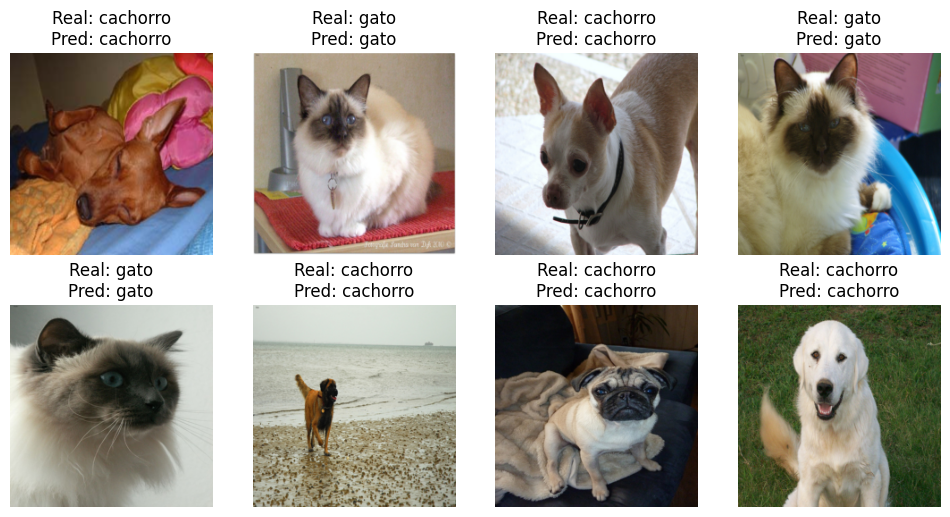

In [14]:
class_names = ["gato", "cachorro"]

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))

for i in range(min(8, len(images))):

    img = images[i].permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(
        f"Real: {class_names[labels[i]]}\n"
        f"Pred: {class_names[preds[i]]}"
    )
    plt.axis("off")

plt.show()

15. Gráficos de desempenho

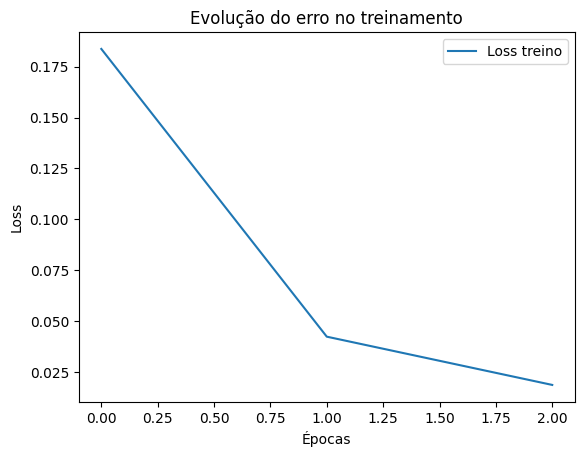

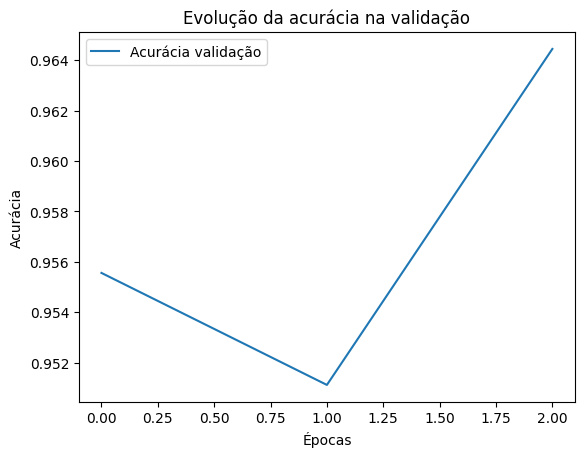

In [15]:
plt.plot(train_losses, label="Loss treino")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Evolução do erro no treinamento")
plt.legend()
plt.show()

plt.plot(val_accuracies, label="Acurácia validação")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.title("Evolução da acurácia na validação")
plt.legend()
plt.show()